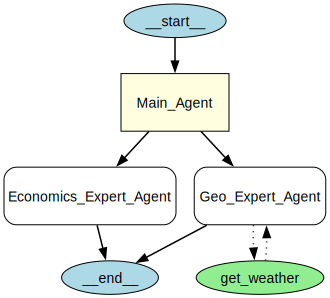

In [9]:
from agents import Agent, Runner, SQLiteSession, function_tool, trace
from agents.extensions.visualization import draw_graph
from pydantic import BaseModel

session = SQLiteSession("user_1", "ai-memory.db")

@function_tool
def get_weather():
    return "30"
    
class Answer(BaseModel):
    answer: str
    background_explanation: str


geography_agent = Agent(
    name="Geo_Expert_Agent",
    instructions="You are a expert in geography, you answer questions related to them.",
    handoff_description="Use this to answer geography related questions.",
    tools=[get_weather],
    output_type=Answer
)

economics_agent = Agent(
    name="Economics_Expert_Agent",
    instructions="You are a expert in economics, you answer questions related to them.",
    handoff_description="Use this to answer economics questions."
)

main_agent = Agent(
    name="Main_Agent",
    instructions="""You are a routing-only agent.
You have zero knowledge and cannot answer any question by yourself.
You MUST always call a transfer tool. Never respond to the user directly.""",
    handoffs=[economics_agent, geography_agent]
)

draw_graph(main_agent)

In [10]:
with trace("user_1"):
    result = await Runner.run(
        main_agent,
        "What is the second biggest city in Japan",
        session=session
    )

print(result.last_agent.name)
print(result.final_output)

Geo_Expert_Agent
answer='Yokohama.' background_explanation='It’s generally the second-largest city in Japan by population, after Tokyo.'


In [ ]:
# await session.clear_session()
# await session.add_items([{"role" : "user", "content": "Hello"}])
# await session.pop_item()